### BLOQUE 0 — Setup (paths)

In [78]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

BASE_DIR = Path.cwd()
RAW = BASE_DIR / "raw"

print("BASE_DIR:", BASE_DIR)
print("RAW:", RAW)
print("Archivos:", [p.name for p in sorted(RAW.glob("*"))])

BASE_DIR: /Users/emiliahernandez/Desktop/Banxico/recuadro
RAW: /Users/emiliahernandez/Desktop/Banxico/recuadro/raw
Archivos: ['DEXMXUS.csv', 'DGS10.csv', 'EMBIG.csv', 'IGAE_2.xlsx', 'INPC.csv', 'NASDAQ100.csv', 'SP500.csv', 'VIXCLS.csv', 'cetes_28_banxico_diario.csv', 'qqq_us_d.csv', 'spy_us_d.csv']


## BLOQUE 1 — Helpers de fechas (clave para que no haya NaNs por desalineación)

In [79]:
def to_month_start(s):
    s = pd.to_datetime(s, errors="coerce")
    # forma robusta: convertir a periodo mensual y luego a timestamp (inicio de mes)
    p = s.dt.to_period("M")
    return p.dt.start_time

def ensure_month_start_df(df, date_col="date"):
    df = df.copy()
    df[date_col] = to_month_start(df[date_col])
    return df

## BLOQUE 2 — Lectores correctos por archivo
2A) FRED mensual (DGS10, VIXCLS) — NO resamplear

In [80]:
def read_fred_monthly_csv(path: Path, value_col: str) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    df = df.rename(columns={"observation_date": "date"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df["date"] = to_month_start(df["date"])
    df = df[["date", value_col]].dropna().sort_values("date").reset_index(drop=True)
    return df

2B) FRED diario (DEXMXUS si viene diario) — resample a mensual

In [81]:
def read_fred_daily_csv(path: Path, value_col: str) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    df = df.rename(columns={"observation_date": "date"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[["date", value_col]].dropna().sort_values("date").reset_index(drop=True)
    return df

def daily_to_monthly(df_daily: pd.DataFrame, col: str, how="last") -> pd.DataFrame:
    x = df_daily.copy()
    x["date"] = pd.to_datetime(x["date"])
    x = x.sort_values("date").set_index("date")

    if how == "mean":
        out = x[col].resample("MS").mean()
    else:
        out = x[col].resample("MS").last()

    return out.reset_index().rename(columns={col: col})

2C) Stooq diario (QQQ/SPY) + retornos log diarios

In [82]:
def read_stooq_daily(path: Path, price_col="Close") -> pd.DataFrame:
    df = pd.read_csv(path).copy()

    # stooq típico: Date, Open, High, Low, Close, Volume
    # a veces vienen en minúsculas; normalizamos
    cols = {c.lower(): c for c in df.columns}
    date_col = cols.get("date", df.columns[0])

    # precio (Close)
    if price_col not in df.columns:
        # intenta close
        if cols.get("close"):
            price_col = cols["close"]
        else:
            raise ValueError(f"No encontré columna Close en {path.name}. Columnas: {df.columns.tolist()}")

    df = df.rename(columns={date_col: "date", price_col: "value"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["date","value"]).sort_values("date").reset_index(drop=True)
    return df[["date","value"]]

def make_log_returns(df_price: pd.DataFrame, name: str) -> pd.DataFrame:
    out = df_price.copy().sort_values("date")
    out = out[out["value"] > 0]
    out[f"r_{name}"] = np.log(out["value"]).diff()
    return out.dropna(subset=[f"r_{name}"])[["date", f"r_{name}"]]

2D) EMBIG (BCRP con meses en español) + mensual last

In [83]:
def read_embig_bcrp_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        encoding="latin-1",
        skiprows=4,
        header=None,
        names=["date_raw", "value_raw"],
        engine="python"
    ).dropna(subset=["date_raw","value_raw"]).copy()

    month_map = {
        "Ene": "Jan", "Feb": "Feb", "Mar": "Mar", "Abr": "Apr",
        "May": "May", "Jun": "Jun", "Jul": "Jul", "Ago": "Aug",
        "Sep": "Sep", "Oct": "Oct", "Nov": "Nov", "Dic": "Dec"
    }

    s = df["date_raw"].astype(str).str.strip()
    s = s.str.replace(
        r"(\d{2})([A-Za-zÁÉÍÓÚáéíóúÑñ]{3})(\d{2})",
        lambda m: m.group(1) + month_map.get(m.group(2).title(), m.group(2).title()) + m.group(3),
        regex=True
    )

    df["date"] = pd.to_datetime(s, format="%d%b%y", errors="coerce")
    df["EMBIG"] = pd.to_numeric(df["value_raw"], errors="coerce")

    df = df[["date","EMBIG"]].dropna().sort_values("date").reset_index(drop=True)
    return df

def embig_monthly_last(df_embig_daily: pd.DataFrame) -> pd.DataFrame:
    return daily_to_monthly(df_embig_daily, "EMBIG", how="last")

2E) INPC mensual (si tu INPC.csv ya es 2 columnas: fecha + INPC)

In [84]:
def read_inpc_simple_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    # intenta detectar columna fecha / valor
    df.columns = [c.strip() for c in df.columns]
    date_col = None
    for c in df.columns:
        if c.lower() in ["date","fecha","periodo","period"]:
            date_col = c
            break
    if date_col is None:
        date_col = df.columns[0]

    # valor: la columna numérica con más obs
    candidates = [c for c in df.columns if c != date_col]
    best = max(candidates, key=lambda c: pd.to_numeric(df[c], errors="coerce").notna().sum())
    df = df.rename(columns={date_col:"date", best:"INPC"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["INPC"] = pd.to_numeric(df["INPC"], errors="coerce")

    df["date"] = to_month_start(df["date"])
    df = df[["date","INPC"]].dropna().sort_values("date").reset_index(drop=True)
    return df

2F) IGAE desde tu Excel (dejo tu función si ya te sirve; si no, uso esta robusta)

In [85]:
# ---- helpers: mes robusto (acepta "Eneroᵖ", "Enero*", "Enero P", etc.) ----
MONTH_PREFIX = {
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "oct":10, "nov":11, "dic":12
}

def month_num_from_header(x: str):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = str(x).strip().lower()
    # deja solo letras (incluye acentos/ñ)
    s = re.sub(r"[^a-záéíóúüñ]", "", s)
    # normaliza septiembre (a veces "setiembre")
    if s.startswith("set"):
        s = "sep" + s[3:]
    pref = s[:3]
    return MONTH_PREFIX.get(pref)

def read_igae_excel(path, sheet_name="Tabulado", concept_name="Total"):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # fila donde empieza la tabla (Concepto)
    concept_row = raw.index[raw.iloc[:,0].astype(str).str.contains("Concepto", na=False)].tolist()
    if not concept_row:
        raise ValueError("No encontré la fila 'Concepto' en la primera columna.")
    start = concept_row[0]

    tab = raw.iloc[start:].copy().reset_index(drop=True)

    # localizar fila de años (busca 1993..2026 en primeras filas)
    year_row_idx = None
    for r in range(0, 10):
        row = tab.iloc[r].astype(str).str.strip()
        if row.str.contains(r"(19|20)\d{2}", na=False).any():
            year_row_idx = r
            break
    if year_row_idx is None:
        raise ValueError("No pude ubicar una fila con años (1993...2026).")

    year_row = tab.iloc[year_row_idx].astype(str).str.strip()

    # fila de meses: normalmente está abajo del año, pero puede variar;
    # probamos year_row_idx+1, si no sirve, usamos year_row_idx+2.
    month_row_idx = min(year_row_idx + 1, tab.shape[0] - 1)
    header_months = tab.iloc[month_row_idx].astype(str).str.strip()

    # datos empiezan más abajo
    data_start = max(month_row_idx + 1, year_row_idx + 2)
    data = tab.iloc[data_start:].copy()
    data.columns = range(data.shape[1])

    # encontrar el renglón del concepto (Total)
    concept_col = 0
    cm = data[concept_col].astype(str).str.strip().eq(concept_name)
    if not cm.any():
        cm = data[concept_col].astype(str).str.contains(r"^Total$", na=False)
    if not cm.any():
        raise ValueError(f"No encontré el concepto '{concept_name}' en la primera columna.")
    row_idx = cm.idxmax()
    row_vals = data.loc[row_idx]

    # detectar columnas-año (extrae 1993..2026 aunque venga como "2025P")
    years_by_col = {}
    for c, txt in enumerate(year_row):
        m = re.search(r"(19|20)\d{2}", str(txt))
        if m:
            years_by_col[c] = int(m.group(0))
    if not years_by_col:
        raise ValueError("No detecté columnas-año en los encabezados.")

    out = []
    ncols = data.shape[1]

    for c0, y in sorted(years_by_col.items(), key=lambda x: x[0]):
        # buscar el primer mes a la derecha de la columna del año (rango amplio)
        start_month_col = None
        for c in range(c0, min(c0 + 30, ncols)):
            if month_num_from_header(header_months.iloc[c]) == 1:  # Enero (aunque sea "Eneroᵖ")
                start_month_col = c
                break
        if start_month_col is None:
            continue  # no pude ubicar Enero para ese año

        # leer 12 meses consecutivos
        for c in range(start_month_col, min(start_month_col + 12, ncols)):
            mnum = month_num_from_header(header_months.iloc[c])
            if mnum is None:
                break
            v = row_vals.iloc[c]
            if pd.isna(v):
                continue
            out.append({"date": pd.Timestamp(y, mnum, 1), "IGAE": float(v)})

    igae = (pd.DataFrame(out)
            .sort_values("date")
            .drop_duplicates("date")
            .reset_index(drop=True))

    if igae.empty:
        raise ValueError("IGAE salió vacío: no encontré meses/valores en los bloques-año.")

    return igae

In [86]:
# ---------- INPC: detectar dónde empiezan los datos ----------
MONTHS_ES = {
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dic": 12
}

def parse_inpc_period(s: str):
    """
    Convierte strings tipo 'Ene 1970' o 'Ene-1970' a Timestamp del 1er día del mes.
    """
    s = str(s).strip().lower().replace(".", "")
    # patrones comunes: "Ene 1970", "Ene-1970", "Ene1970"
    m = re.search(r"([a-zñ]{3})[\s\-]?(\d{4})", s)
    if not m:
        return pd.NaT
    mon = MONTHS_ES.get(m.group(1)[:3], None)
    yr = int(m.group(2))
    if mon is None:
        return pd.NaT
    return pd.Timestamp(year=yr, month=mon, day=1)

def find_inpc_data_start_line(path: Path, encoding="latin-1", max_lines=5000) -> int:
    """
    Encuentra la primera línea que 'parece' dato:
    algo que contenga un mes (Ene/Feb/...) y un año 4 dígitos,
    y además una coma después (porque el archivo es CSV).
    """
    pat = re.compile(r'(Ene|Feb|Mar|Abr|May|Jun|Jul|Ago|Sep|Oct|Nov|Dic)[\s\-]?\d{4}', re.IGNORECASE)
    with open(path, "r", encoding=encoding, errors="replace") as f:
        for i, line in enumerate(f):
            if i > max_lines:
                break
            if pat.search(line) and "," in line:
                return i
    return 0

def read_inpc_inegi_csv(path: Path) -> pd.DataFrame:
    # 1) encontrar inicio real de datos
    start = find_inpc_data_start_line(path, encoding="latin-1")
    # 2) leer desde ahí: esperamos 2 columnas (Periodo, Valor) al menos para el INPC general
    df = pd.read_csv(
        path,
        encoding="latin-1",
        skiprows=start,
        header=None,
        engine="python",
        on_bad_lines="skip"
    )
    # Nos quedamos con las primeras 2 columnas
    df = df.iloc[:, :2]
    df.columns = ["period_raw", "value_raw"]
    # 3) parseo
    df["date"] = df["period_raw"].apply(parse_inpc_period)
    df["value"] = pd.to_numeric(df["value_raw"], errors="coerce")
    out = df[["date", "value"]].dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    # Filtro: en INPC es normal que empiece 1970, pero nosotros luego recortamos muestra
    return out


## BLOQUE 3 — Cargar series (aquí ya se arregla tu NaN masivo)

In [87]:
# 1) DGS10 y VIX: mensuales ya agregadas
m_dgs10 = read_fred_monthly_csv(RAW / "DGS10.csv", "DGS10")
m_vix   = read_fred_monthly_csv(RAW / "VIXCLS.csv", "VIXCLS")

# 2) FX: normalmente diario en FRED -> mensual last
m_fx  = read_fred_monthly_csv(RAW / "DEXMXUS.csv", "DEXMXUS")


# 3) EMBIG: diario con meses en español -> mensual last
embig_d = read_embig_bcrp_csv(RAW / "EMBIG.csv")
m_embig = embig_monthly_last(embig_d)

# 4) INPC mensual
m_inpc = read_inpc_inegi_csv(RAW / "INPC.csv")

# 5) IGAE mensual (si tu read_igae_excel del notebook ya funciona, úsala y solo asegúrate de month-start)
m_igae = read_igae_excel(RAW / "IGAE_2.xlsx")
# si tú ya tenías igae DataFrame, entonces solo:
# m_igae = ensure_month_start_df(igae.rename(columns={"value":"IGAE"}), "date")[["date","IGAE"]]

# 6) QQQ/SPY diarios -> retornos diarios -> retornos mensuales (sum)
qqq_d = read_stooq_daily(RAW / "qqq_us_d.csv")
spy_d = read_stooq_daily(RAW / "spy_us_d.csv")

qqq_r = make_log_returns(qqq_d, "QQQ")
spy_r = make_log_returns(spy_d, "SPY")

rets_d = qqq_r.merge(spy_r, on="date", how="inner").sort_values("date").reset_index(drop=True)
rets_d["tech_rel"] = rets_d["r_QQQ"] - rets_d["r_SPY"]

# a mensual: sum de retornos log diarios
m_r_spy = (rets_d.set_index("date")["r_SPY"].resample("MS").sum().reset_index().rename(columns={"r_SPY":"r_SPY"}))
m_tech  = (rets_d.set_index("date")["tech_rel"].resample("MS").sum().reset_index().rename(columns={"tech_rel":"tech_rel"}))

# 7) estandariza fechas a month-start en TODO
for name, df in {
    "m_dgs10": m_dgs10, "m_vix": m_vix, "m_fx": m_fx, "m_embig": m_embig,
    "m_inpc": m_inpc, "m_igae": m_igae, "m_r_spy": m_r_spy, "m_tech": m_tech
}.items():
    if "date" in df.columns:
        df["date"] = to_month_start(df["date"])

/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_62541/488437261.py:34: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if row.str.contains(r"(19|20)\d{2}", na=False).any():


In [88]:
m_inpc

,date,value
0,1998-01-01,34.003924
1,1998-02-01,34.599238
2,1998-03-01,35.004533
3,1998-04-01,35.332042
4,1998-05-01,35.613481
...,...,...
332,2025-09-01,141.197000
333,2025-10-01,141.708000
334,2025-11-01,142.645000
335,2025-12-01,143.042000


In [89]:
# Normaliza nombres (tu INPC viene como 'value')
if "value" in m_inpc.columns and "INPC" not in m_inpc.columns:
    m_inpc = m_inpc.rename(columns={"value": "INPC"})

if "value" in m_igae.columns and "IGAE" not in m_igae.columns:
    m_igae = m_igae.rename(columns={"value": "IGAE"})

## BLOQUE 4 — Diagnóstico (para confirmar que ya no “desaparecieron” DGS10/VIX/DEXMXUS)

In [90]:
def quick_range(df, col):
    return (df["date"].min().date(), df["date"].max().date(), df[col].notna().sum(), len(df))

print("DGS10:", quick_range(m_dgs10, "DGS10"))
print("VIX:",  quick_range(m_vix, "VIXCLS"))
print("FX:",   quick_range(m_fx, "DEXMXUS"))
print("EMBIG:",quick_range(m_embig, "EMBIG"))
print("INPC:", quick_range(m_inpc, "INPC"))
print("IGAE:", quick_range(m_igae, "IGAE"))
print("tech_rel:", quick_range(m_tech, "tech_rel"))

DGS10: (datetime.date(1998, 1, 1), datetime.date(2026, 1, 1), np.int64(337), 337)
VIX: (datetime.date(1990, 1, 1), datetime.date(2026, 1, 1), np.int64(433), 433)
FX: (datetime.date(1993, 12, 1), datetime.date(2026, 1, 1), np.int64(386), 386)
EMBIG: (datetime.date(1998, 1, 1), datetime.date(2026, 2, 1), np.int64(310), 338)
INPC: (datetime.date(1998, 1, 1), datetime.date(2026, 1, 1), np.int64(337), 337)
IGAE: (datetime.date(1993, 1, 1), datetime.date(2025, 11, 1), np.int64(395), 395)
tech_rel: (datetime.date(2005, 2, 1), datetime.date(2026, 2, 1), np.int64(253), 253)


## BLOQUE 5 — Panel mensual (merge correcto)

In [91]:
dfs = [m_igae, m_inpc, m_fx, m_dgs10, m_vix, m_embig, m_tech]
df_m = dfs[0]
for d in dfs[1:]:
    df_m = df_m.merge(d, on="date", how="inner")

df_m = df_m.sort_values("date").reset_index(drop=True)

# recorte muestra objetivo
df_m = df_m[(df_m["date"] >= "2006-01-01") & (df_m["date"] <= "2025-12-01")].copy()

print("Panel mensual:", df_m.shape, "|", df_m["date"].min().date(), "->", df_m["date"].max().date())
df_m.head(12)

Panel mensual: (239, 8) | 2006-01-01 -> 2025-11-01


,date,IGAE,INPC,DEXMXUS,DGS10,VIXCLS,EMBIG,tech_rel
11,2006-01-01,79.264683,60.603626,10.5422,4.42,12.04,132.0,0.014524
12,2006-02-01,76.806691,60.696358,10.4842,4.57,12.47,122.0,-0.026925
13,2006-03-01,82.035548,60.772512,10.7493,4.72,11.69,140.0,0.008134
14,2006-04-01,79.666903,60.861617,11.0489,4.99,11.85,135.0,-0.014228
15,2006-05-01,84.410932,60.590675,11.0908,5.11,14.45,157.0,-0.045053
16,2006-06-01,83.279664,60.642998,11.3934,5.11,16.92,154.0,0.001474
17,2006-07-01,80.640959,60.809294,10.9830,5.09,15.33,135.0,-0.048739
18,2006-08-01,82.410438,61.119609,10.8735,4.88,13.35,130.0,0.025304
19,2006-09-01,82.162540,61.736612,10.9888,4.72,12.18,NaN,0.023667
20,2006-10-01,83.526199,62.006519,10.8854,4.73,11.31,132.0,0.014740


## BLOQUE 5 — Panel mensual (merge correcto)

In [92]:
dfs = [m_igae, m_inpc, m_fx, m_dgs10, m_vix, m_embig, m_tech]
df_m = dfs[0]
for d in dfs[1:]:
    df_m = df_m.merge(d, on="date", how="inner")

df_m = df_m.sort_values("date").reset_index(drop=True)

# recorte muestra objetivo
df_m = df_m[(df_m["date"] >= "2006-01-01") & (df_m["date"] <= "2025-12-01")].copy()

print("Panel mensual:", df_m.shape, "|", df_m["date"].min().date(), "->", df_m["date"].max().date())
df_m.head(12)

Panel mensual: (239, 8) | 2006-01-01 -> 2025-11-01


,date,IGAE,INPC,DEXMXUS,DGS10,VIXCLS,EMBIG,tech_rel
11,2006-01-01,79.264683,60.603626,10.5422,4.42,12.04,132.0,0.014524
12,2006-02-01,76.806691,60.696358,10.4842,4.57,12.47,122.0,-0.026925
13,2006-03-01,82.035548,60.772512,10.7493,4.72,11.69,140.0,0.008134
14,2006-04-01,79.666903,60.861617,11.0489,4.99,11.85,135.0,-0.014228
15,2006-05-01,84.410932,60.590675,11.0908,5.11,14.45,157.0,-0.045053
16,2006-06-01,83.279664,60.642998,11.3934,5.11,16.92,154.0,0.001474
17,2006-07-01,80.640959,60.809294,10.9830,5.09,15.33,135.0,-0.048739
18,2006-08-01,82.410438,61.119609,10.8735,4.88,13.35,130.0,0.025304
19,2006-09-01,82.162540,61.736612,10.9888,4.72,12.18,NaN,0.023667
20,2006-10-01,83.526199,62.006519,10.8854,4.73,11.31,132.0,0.014740


## BLOQUE 6 — Transformaciones para VAR (sin inventar imputaciones)

In [93]:
df_est = df_m.copy()

df_est["infl_m"] = 100 * (np.log(df_est["INPC"]) - np.log(df_est["INPC"].shift(1)))
df_est["g_igae"] = 100 * (np.log(df_est["IGAE"]) - np.log(df_est["IGAE"].shift(1)))
df_est["dlog_fx"] = 100 * (np.log(df_est["DEXMXUS"]) - np.log(df_est["DEXMXUS"].shift(1)))

# chequeo NA share
print(df_est.isna().mean().sort_values(ascending=False).head(12))

df_est[["date","IGAE","g_igae","INPC","infl_m","DEXMXUS","dlog_fx","DGS10","VIXCLS","EMBIG","tech_rel"]].head(15)

EMBIG       0.083682
infl_m      0.004184
g_igae      0.004184
dlog_fx     0.004184
date        0.000000
IGAE        0.000000
INPC        0.000000
DEXMXUS     0.000000
DGS10       0.000000
VIXCLS      0.000000
tech_rel    0.000000
dtype: float64


,date,IGAE,g_igae,INPC,infl_m,DEXMXUS,dlog_fx,DGS10,VIXCLS,EMBIG,tech_rel
11,2006-01-01,79.264683,NaN,60.603626,NaN,10.5422,NaN,4.42,12.04,132.0,0.014524
12,2006-02-01,76.806691,-3.150090,60.696358,0.152897,10.4842,-0.551689,4.57,12.47,122.0,-0.026925
13,2006-03-01,82.035548,6.586090,60.772512,0.125389,10.7493,2.497127,4.72,11.69,140.0,0.008134
14,2006-04-01,79.666903,-2.929843,60.861617,0.146514,11.0489,2.749024,4.99,11.85,135.0,-0.014228
15,2006-05-01,84.410932,5.784268,60.590675,-0.446172,11.0908,0.378506,5.11,14.45,157.0,-0.045053
16,2006-06-01,83.279664,-1.349252,60.642998,0.086319,11.3934,2.691830,5.11,16.92,154.0,0.001474
17,2006-07-01,80.640959,-3.219769,60.809294,0.273845,10.9830,-3.668562,5.09,15.33,135.0,-0.048739
18,2006-08-01,82.410438,2.170540,61.119609,0.509011,10.8735,-1.001999,4.88,13.35,130.0,0.025304
19,2006-09-01,82.162540,-0.301263,61.736612,1.004440,10.9888,1.054794,4.72,12.18,NaN,0.023667
20,2006-10-01,83.526199,1.646086,62.006519,0.436238,10.8854,-0.945413,4.73,11.31,132.0,0.014740


## BLOQUE 7 — df_var listo (sin NaNs)

In [94]:
var_cols = [
    "tech_rel",
    "VIXCLS",
    "DGS10",
    "EMBIG",
    "dlog_fx",
    "infl_m",
    "g_igae",
]

df_var = df_est[["date"] + var_cols].dropna().copy().set_index("date")

print("Muestra VAR:", df_var.shape, "|", df_var.index.min().date(), "->", df_var.index.max().date())
df_var.head()

Muestra VAR: (218, 7) | 2006-02-01 -> 2025-11-01


,tech_rel,VIXCLS,DGS10,EMBIG,dlog_fx,infl_m,g_igae
date,,,,,,,
2006-02-01,-0.026925,12.47,4.57,122.0,-0.551689,0.152897,-3.150090
2006-03-01,0.008134,11.69,4.72,140.0,2.497127,0.125389,6.586090
2006-04-01,-0.014228,11.85,4.99,135.0,2.749024,0.146514,-2.929843
2006-05-01,-0.045053,14.45,5.11,157.0,0.378506,-0.446172,5.784268
2006-06-01,0.001474,16.92,5.11,154.0,2.691830,0.086319,-1.349252


# Estimación VAR

## BLOQUE 8 — Selección de rezagos (AIC, BIC, HQ)

In [95]:
from statsmodels.tsa.api import VAR

model = VAR(df_var)

maxlags = 12  # mensual → hasta 12 es estándar
lag_order_results = model.select_order(maxlags=maxlags)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        8.208       8.321       3671.       8.254
1        1.038      1.942*       2.823      1.404*
2      0.7605*       2.457      2.143*       1.447
3       0.8514       3.339       2.356       1.858
4       0.8096       4.089       2.277       2.136
5       0.7891       4.860       2.258       2.436
6       0.9030       5.766       2.577       2.870
7       0.9306       6.585       2.718       3.217
8        1.099       7.544       3.328       3.706
9        1.112       8.349       3.527       4.039
10       1.035       9.064       3.459       4.282
11       1.139       9.959       4.123       4.706
12       1.207       10.82       4.822       5.095
--------------------------------------------------


/Users/emiliahernandez/Desktop/Banxico/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [96]:
num = 2
num = lag_order_results.selected_orders["bic"]
print("Rezagos elegidos (BIC):", 2)

Rezagos elegidos (BIC): 2


## BLOQUE 9 — Estimar el VAR

In [97]:
var_res = model.fit(num)

print(var_res.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 21, Feb, 2026
Time:                     21:45:32
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    1.77908
Nobs:                     217.000    HQIC:                   1.25919
Log likelihood:          -2197.76    FPE:                    2.47708
AIC:                     0.906845    Det(Omega_mle):         1.92256
--------------------------------------------------------------------
Results for equation tech_rel
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.002223         0.007414           -0.300           0.764
L1.tech_rel         0.019112         0.067925            0.281           0.778
L1.VIXCLS           0.000284         0.000216            1.314   

## Selección de rezagos del VAR: criterios de información (AIC y BIC)

Para determinar el número óptimo de rezagos del modelo VAR se utilizan los criterios de información de Akaike (AIC) y Bayesiano (BIC). Ambos criterios balancean el ajuste del modelo con su complejidad:

- Un mayor número de rezagos mejora el ajuste in-sample, pero incrementa el número de parámetros y reduce los grados de libertad.
- Los criterios penalizan la complejidad para evitar sobreajuste.

Formalmente:

- **AIC = −2·log(L) + 2k**
- **BIC = −2·log(L) + k·log(T)**

donde:
- \(L\) es la verosimilitud del modelo,
- \(k\) el número de parámetros,
- \(T\) el tamaño de muestra.

El BIC penaliza más fuertemente la inclusión de rezagos adicionales, por lo que suele seleccionar modelos más parsimoniosos.

### Resultado empírico

En este ejercicio, el BIC sugiere un VAR(1), mientras que el AIC apunta a un número mayor de rezagos. Dado que se trabaja con datos mensuales y se busca capturar la dinámica macro-financiera de corto plazo, se adopta un **VAR(2)** como especificación base. Esta elección permite:

- Capturar mejor la persistencia temporal de las variables,
- Reducir el riesgo de autocorrelación en los residuos,
- Mantener un balance entre parsimonia y ajuste del modelo.

Posteriormente se verifica la estabilidad del VAR y la ausencia de autocorrelación en los residuos para validar la especificación seleccionada.

## BLOQUE 10 — Orden Cholesky ( identificación estructural)

Orden es tech_rel → VIX → DGS10 → EMBIG → FX → inflación → actividad

In [98]:
ordered_vars = [
    "tech_rel",
    "VIXCLS",
    "DGS10",
    "EMBIG",
    "dlog_fx",
    "infl_m",
    "g_igae",
]
df_var_chol = df_var[ordered_vars]
model_chol = VAR(df_var_chol).fit(num)

/Users/emiliahernandez/Desktop/Banxico/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## BLOQUE 11 — IRFs (funciones impulso-respuesta)

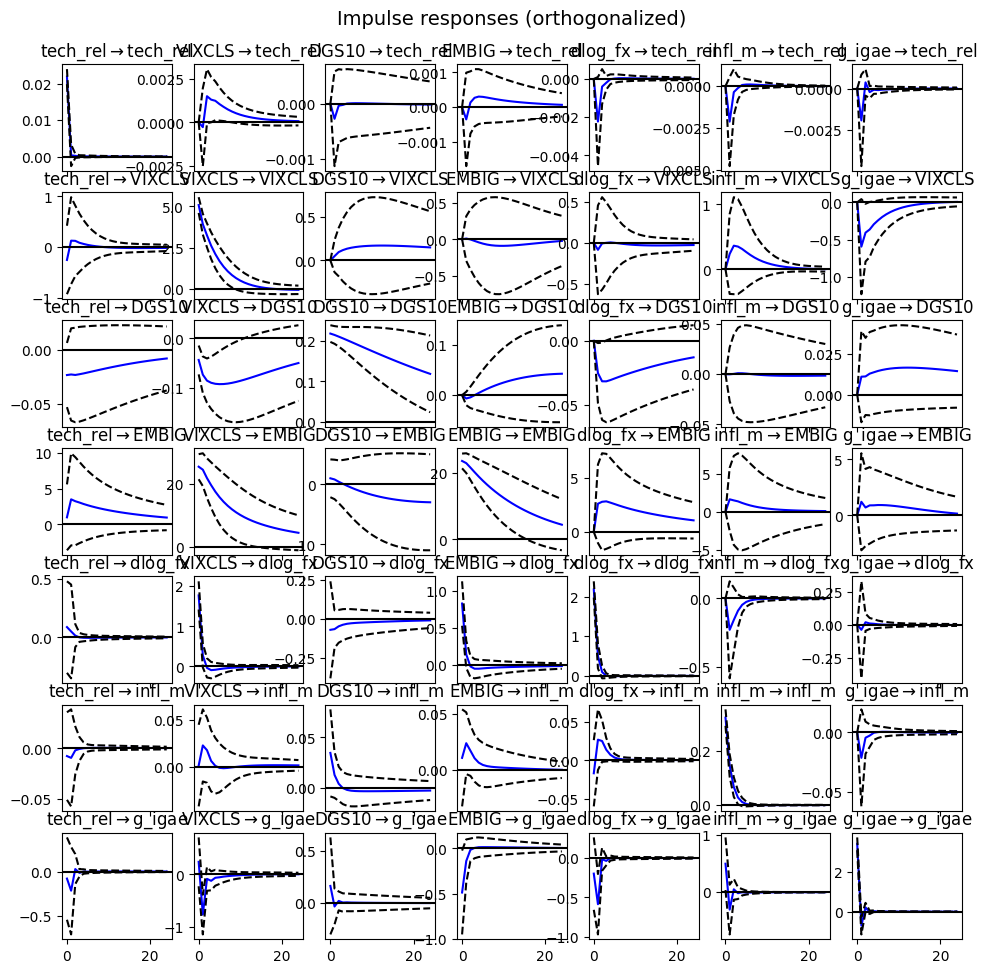

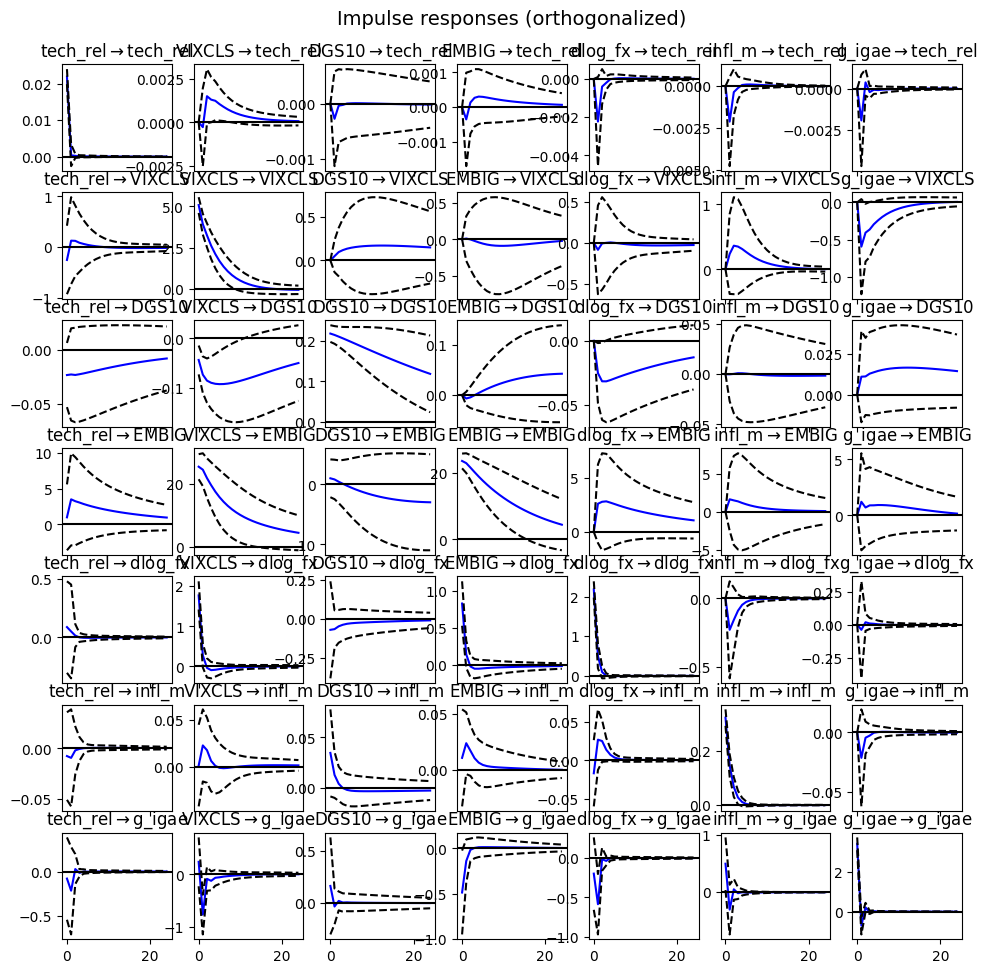

In [99]:
h = 24  # 2 años

irf = model_chol.irf(h)
irf.plot(orth=True)


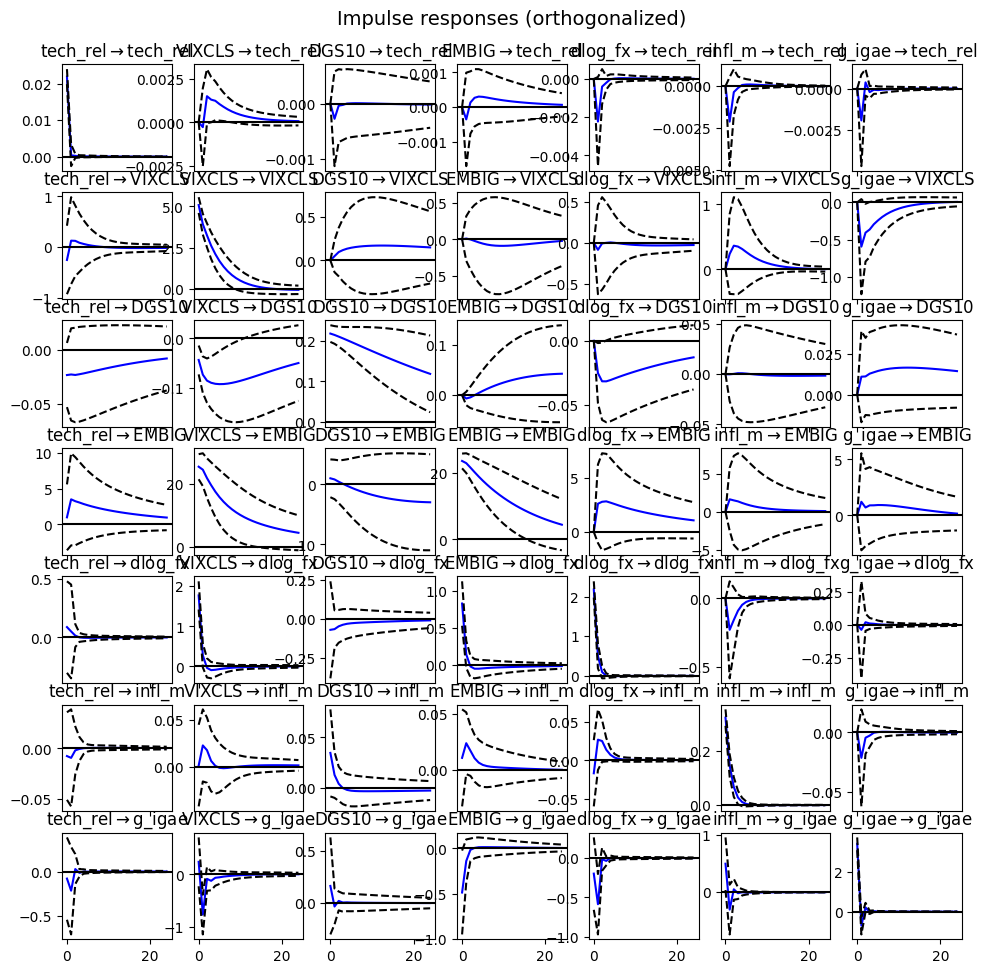

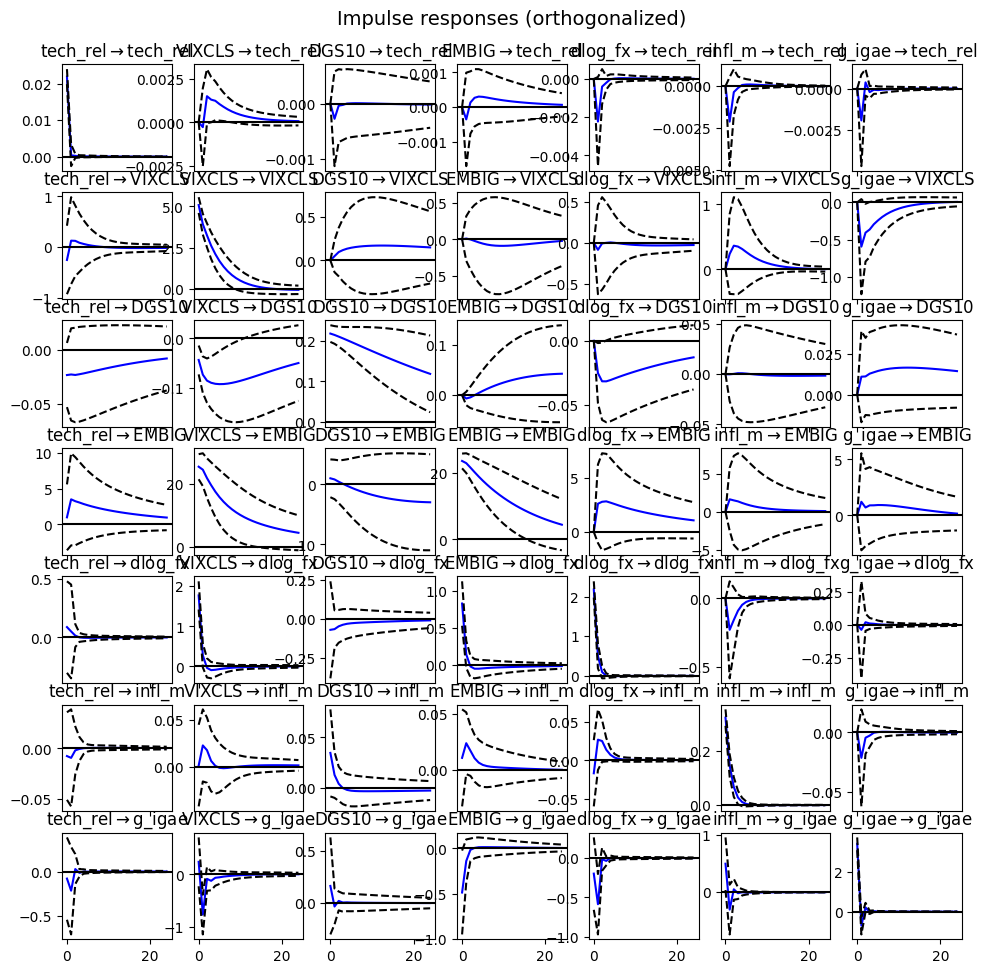

In [100]:
irf.plot(orth=True, signif=0.05)

## BLOQUE 12 — Respuesta a shock tecnológico (tu variable clave)

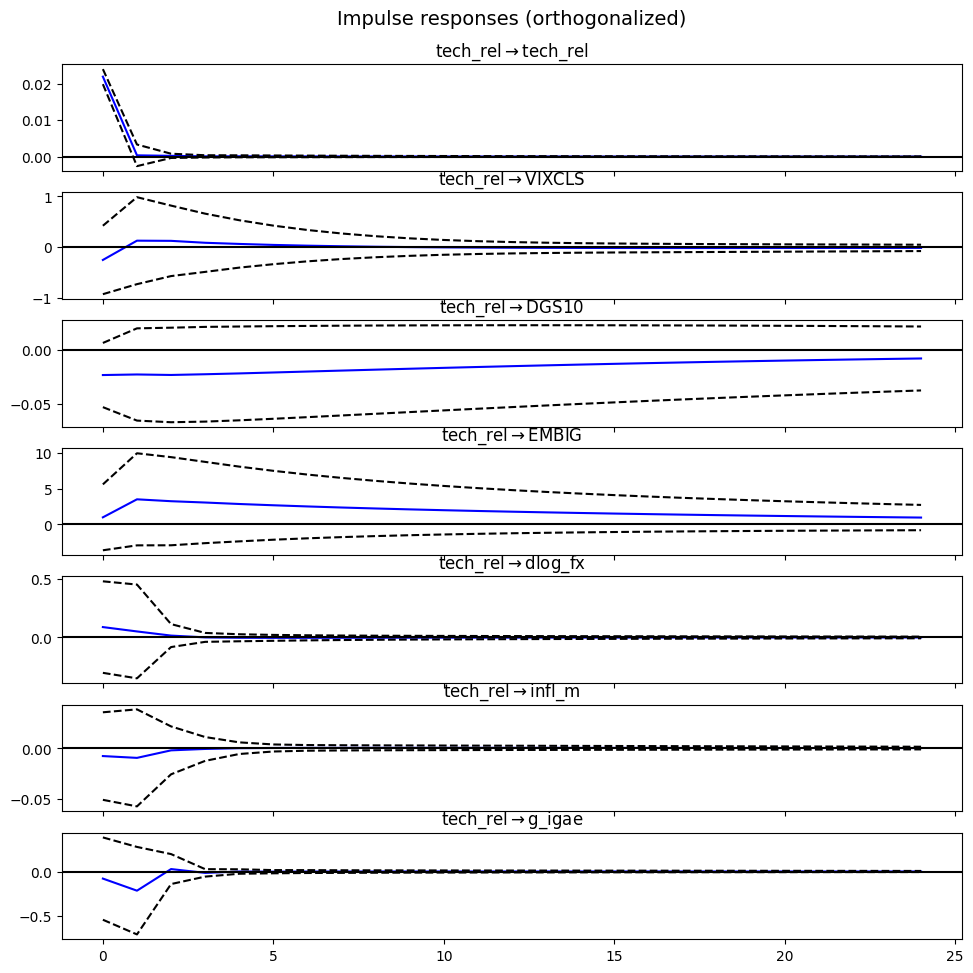

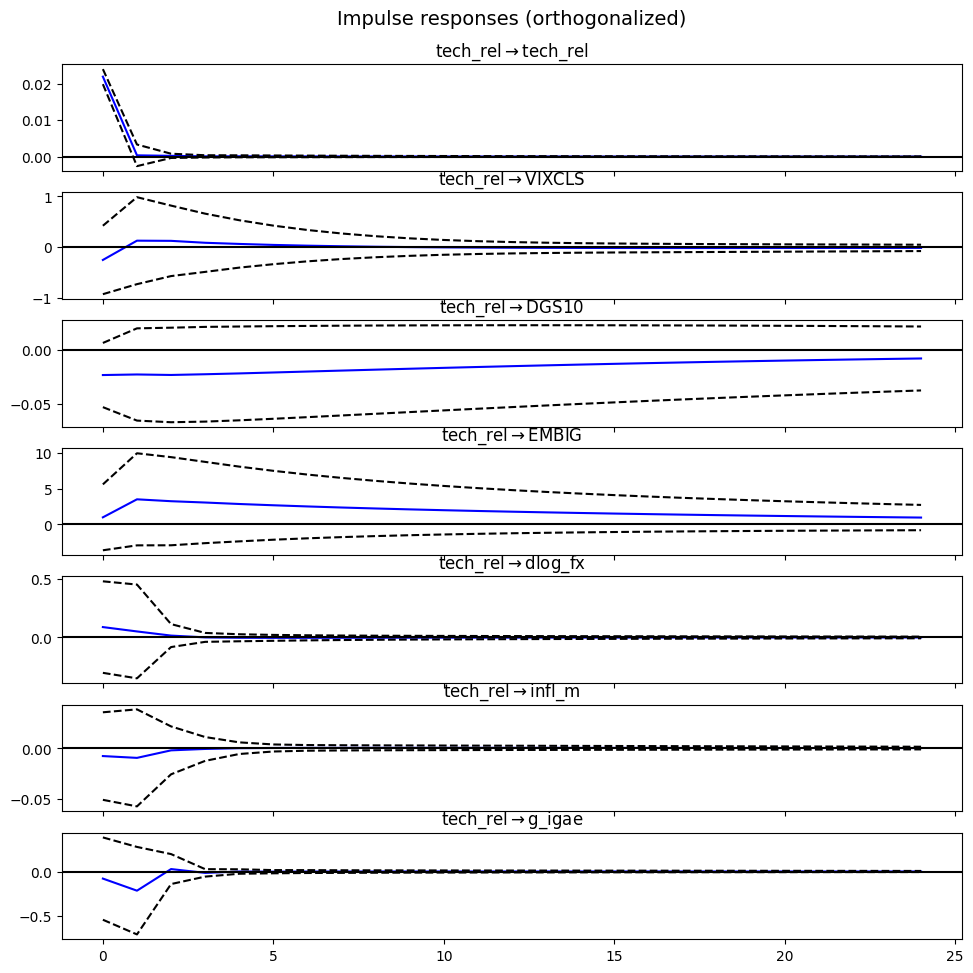

In [101]:
irf.plot(impulse="tech_rel", orth=True)


## Funciones Impulso–Respuesta: Shock tecnológico en EE.UU. (tech_rel)

Se analiza la transmisión de un shock positivo en la variable `tech_rel` (rendimiento relativo del Nasdaq respecto al S&P 500), interpretado como un **shock tecnológico externo**. Bajo la identificación de Cholesky, este shock se considera exógeno para la economía mexicana en el corto plazo.

### Variables externas

**VIX**  
Se observa una respuesta negativa inicial del VIX, consistente con una mejora en las condiciones financieras globales ante un shock tecnológico positivo. Sin embargo, los intervalos de confianza incluyen el cero, por lo que el efecto no es estadísticamente significativo.

**Tasa de interés de largo plazo de EE.UU. (DGS10)**  
La respuesta es ligeramente negativa y persistente, lo que sugiere que el shock tecnológico se asocia con menores tasas reales de largo plazo, posiblemente por expectativas de mayor productividad. No obstante, el efecto es pequeño y no significativo.

### Canales financieros hacia México

**EMBIG (riesgo país)**  
Se observa un aumento transitorio del EMBIG en los primeros meses tras el shock, seguido de una reversión gradual. Este resultado puede interpretarse como un ajuste inicial de portafolios globales hacia activos tecnológicos en EE.UU., que reduce temporalmente la demanda por activos de economías emergentes. El efecto no es estadísticamente significativo en la mayoría de los horizontes.

**Tipo de cambio (dlog_fx)**  
La respuesta del tipo de cambio es cercana a cero y no significativa, lo que sugiere que el canal cambiario no es el principal mecanismo de transmisión de este tipo de shock en el corto plazo.

### Variables domésticas

**Inflación**  
La inflación presenta una respuesta negativa de muy baja magnitud, consistente con un posible efecto desinflacionario asociado a mejoras tecnológicas globales (menores costos de producción y bienes importados más baratos). Sin embargo, el efecto no es estadísticamente significativo.

**Actividad económica (g_igae)**  
La actividad económica muestra una caída inicial en el primer periodo, seguida de una rápida reversión hacia cero. Este patrón es consistente con un efecto de corto plazo dominado por el canal financiero (salida de capitales hacia EE.UU.) que posteriormente se disipa. No se observan efectos persistentes ni significativos sobre la actividad.

### Persistencia del shock

La respuesta de `tech_rel` a su propio shock es de corta duración y se disipa rápidamente, lo que indica baja persistencia del componente inesperado del shock tecnológico en esta especificación.

### Conclusión

En conjunto, los resultados sugieren que un shock tecnológico en EE.UU. tiene efectos limitados y de corta duración sobre las variables macrofinancieras de México en el periodo analizado. Los canales financieros (EMBIG y condiciones globales) reaccionan transitoriamente, mientras que el tipo de cambio, la inflación y la actividad económica no muestran respuestas estadísticamente significativas. Esto es consistente con la hipótesis de que, en el corto plazo, la economía mexicana es más sensible a shocks financieros globales amplios que a shocks tecnológicos específicos del sector tecnológico estadounidense.

## Identificación estructural mediante descomposición de Cholesky

Para interpretar las funciones impulso–respuesta es necesario transformar los choques del VAR reducido en choques estructurales económicamente interpretables. En este ejercicio se utiliza la **identificación de Cholesky**, que impone una estructura recursiva contemporánea sobre las variables del sistema.

### Idea básica

El VAR reducido produce innovaciones que están correlacionadas entre sí. La descomposición de Cholesky permite ortogonalizar estos choques, es decir, construir innovaciones no correlacionadas que pueden interpretarse como **shocks estructurales**.

Formalmente, si la matriz de varianzas–covarianzas de los residuos es:

\[
\Sigma_u
\]

la descomposición de Cholesky encuentra una matriz triangular inferior \(P\) tal que:

\[
\Sigma_u = P P'
\]

Esto implica que los choques estructurales se obtienen como:

\[
\varepsilon_t = P^{-1} u_t
\]

donde \(u_t\) son los residuos del VAR reducido.

### Interpretación económica

La identificación de Cholesky impone que las variables ordenadas primero en el sistema:

- pueden afectar contemporáneamente a las variables que aparecen después,
- pero no son afectadas contemporáneamente por ellas.

Es decir, se asume una **estructura causal contemporánea recursiva**.

### Ordenamiento utilizado

El orden de las variables en el VAR es:

1. `tech_rel` (shock tecnológico externo)
2. `VIXCLS` (condiciones financieras globales)
3. `DGS10` (tasa de largo plazo de EE.UU.)
4. `EMBIG` (riesgo país)
5. `dlog_fx` (tipo de cambio)
6. `infl_m` (inflación)
7. `g_igae` (actividad económica)

Este orden refleja la hipótesis de una **economía pequeña y abierta**, donde:

- los shocks externos son exógenos para México en el corto plazo,
- las variables financieras reaccionan más rápido que las reales,
- la actividad económica responde con mayor rezago.

### Implicaciones

Bajo esta identificación:

- Un shock en `tech_rel` afecta contemporáneamente a todas las demás variables.
- Un shock en `EMBIG` puede afectar al tipo de cambio, la inflación y la actividad en el mismo periodo, pero no a las variables externas.
- La actividad económica (`g_igae`) no afecta contemporáneamente a ninguna otra variable.

Esta estructura permite interpretar las funciones impulso–respuesta como la transmisión dinámica de un shock tecnológico externo hacia la economía mexicana a través de canales financieros y reales.

## BLOQUE 13 — Descomposición de varianza (FEVD)

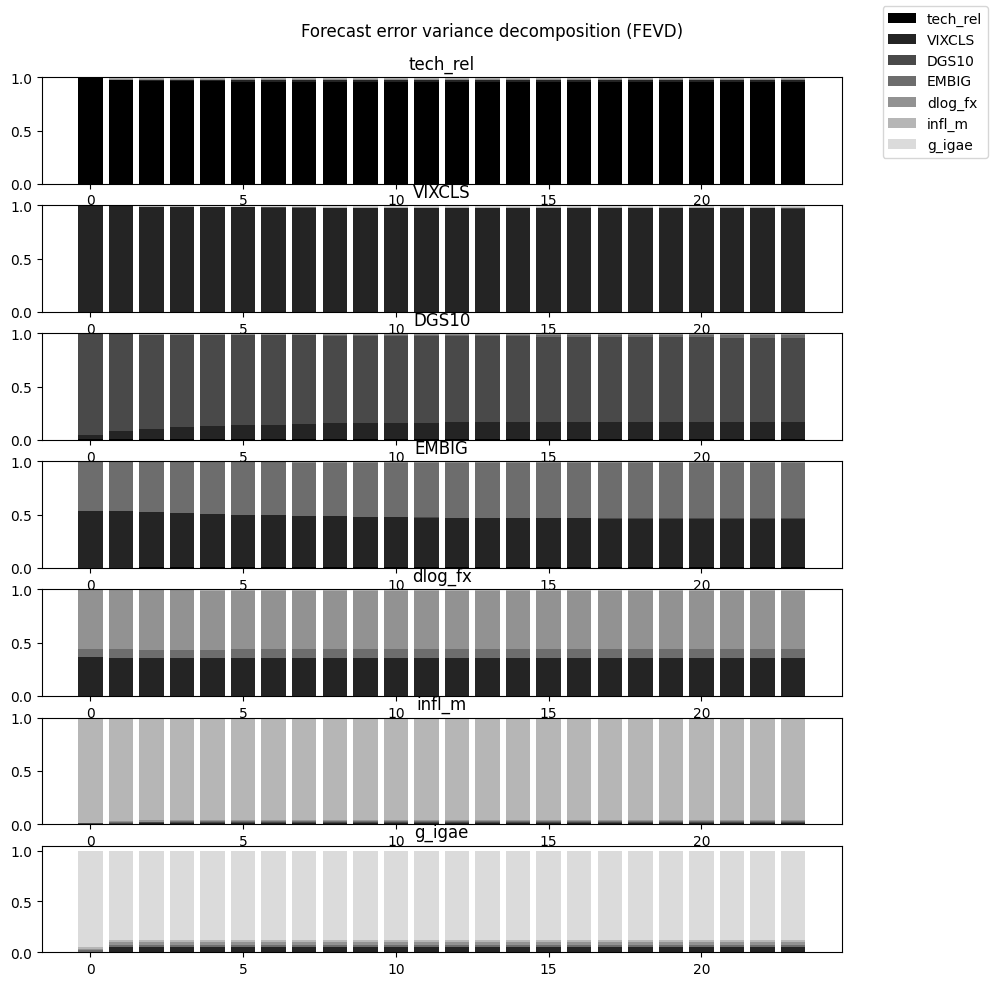

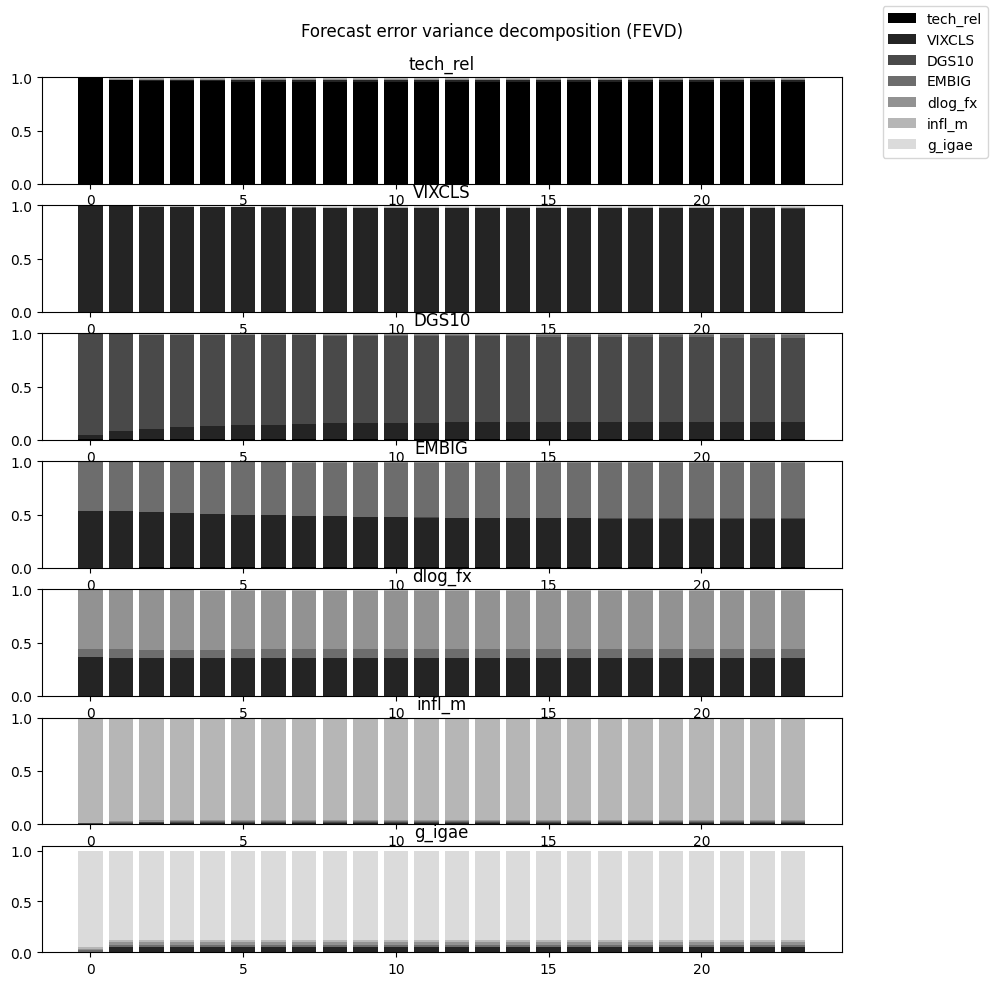

In [102]:
fevd = model_chol.fevd(h)
fevd.plot()

## Checks econométricos recomendados

#### Autocorrelación de residuos

In [103]:
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in df_var_chol.columns:
    lb = acorr_ljungbox(var_res.resid[col], lags=[12], return_df=True)
    print(col, lb)

tech_rel      lb_stat  lb_pvalue
12  16.16465   0.183811
VIXCLS      lb_stat  lb_pvalue
12  5.588522   0.935389
DGS10       lb_stat  lb_pvalue
12  15.467825   0.216844
EMBIG      lb_stat  lb_pvalue
12  9.044252   0.699146
dlog_fx       lb_stat  lb_pvalue
12  15.732582   0.203794
infl_m       lb_stat     lb_pvalue
12  71.161803  1.940538e-10
g_igae        lb_stat     lb_pvalue
12  103.479393  1.155746e-16


#### Normalidad

In [104]:
from scipy.stats import jarque_bera

for col in var_res.resid.columns:
    print(col, jarque_bera(var_res.resid[col]))

tech_rel SignificanceResult(statistic=np.float64(1.9710939907776612), pvalue=np.float64(0.37323501325858))
VIXCLS SignificanceResult(statistic=np.float64(9718.521261509622), pvalue=np.float64(0.0))
DGS10 SignificanceResult(statistic=np.float64(119.78952095267954), pvalue=np.float64(9.728279287842591e-27))
EMBIG SignificanceResult(statistic=np.float64(6037.089503746528), pvalue=np.float64(0.0))
dlog_fx SignificanceResult(statistic=np.float64(1188.6820752043518), pvalue=np.float64(7.602685067724938e-259))
infl_m SignificanceResult(statistic=np.float64(42.90014885531232), pvalue=np.float64(4.834494156750467e-10))
g_igae SignificanceResult(statistic=np.float64(53.62866341406631), pvalue=np.float64(2.2629955696024924e-12))


## Gráficas

#### 5️⃣ Gráficas principales (B1 y B2) con bandas
#### BLOQUE 1 — IRFs + bandas (Monte Carlo) y helper de plots

In [105]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

H = 24
SIGNIF = 0.05
B = 500          # bootstrap replications (sube a 1000 si quieres más suave)
impulse = "tech_rel"
seed = 123

# Datos (deben ser los del VAR ya ordenados por Cholesky)
# df_var_chol: DataFrame con index fecha y columnas en el orden Cholesky
Y = df_var_chol.copy()

# Ajuste base
p = model_chol.k_ar
res = model_chol
k = len(res.names)

idx = {v:i for i,v in enumerate(res.names)}

# IRF base (orth)
irf_base = res.irf(H).orth_irfs  # (H+1,k,k)


# === Bootstrap de IRFs ===
rng = np.random.default_rng(seed)

# Residuos del VAR (T-p x k)
U = res.resid.values
T_eff = U.shape[0]

# Coefs para simular: usamos la forma companion via forecast recursion
# Tomamos los valores iniciales como los primeros p observados reales
Y_values = Y.values
Y_init = Y_values[:p].copy()

def simulate_var(res, Y_init, U_draw):
    """
    Simula VAR usando el modelo estimado 'res', condiciones iniciales Y_init (p x k)
    y una secuencia de shocks U_draw (T_eff x k).
    Devuelve serie simulada completa de longitud p+T_eff (p iniciales + simuladas).
    """
    k = U_draw.shape[1]
    p = res.k_ar
    coefs = res.coefs  # shape (p,k,k) con A1..Ap
    intercept = res.intercept  # shape (k,)

    Y_sim = np.zeros((p + U_draw.shape[0], k))
    Y_sim[:p] = Y_init

    for t in range(p, p + U_draw.shape[0]):
        yhat = intercept.copy()
        for lag in range(1, p+1):
            yhat += coefs[lag-1] @ Y_sim[t-lag]
        Y_sim[t] = yhat + U_draw[t-p]
    return Y_sim

# Guardar IRFs bootstrap
irfs_boot = np.zeros((B, H+1, k, k))

for b in range(B):
    # re-muestreo de residuos con reemplazo (iid bootstrap)
    draw_idx = rng.integers(0, T_eff, size=T_eff)
    U_draw = U[draw_idx]

    # simular serie
    Y_sim = simulate_var(res, Y_init, U_draw)

    # refit VAR al simulado (misma p)
    Yb = pd.DataFrame(Y_sim, columns=res.names)
    mod_b = VAR(Yb).fit(p)

    # IRF orth del bootstrap
    irfs_boot[b] = mod_b.irf(H).orth_irfs

# cuantiles
alpha = SIGNIF/2
lower = np.quantile(irfs_boot, alpha, axis=0)
upper = np.quantile(irfs_boot, 1-alpha, axis=0)
# === Alias con los nombres que usa tu función de gráficas ===
orth = irf_base
varnames = list(res.names)  # para los filtros "if v in varnames"

# sanity check ancho
print("Band width check (tech_rel→EMBIG, h=1):",
      float(upper[1, idx["EMBIG"], idx[impulse]] - lower[1, idx["EMBIG"], idx[impulse]]))


Band width check (tech_rel→EMBIG, h=1): 15.471118099205132


In [106]:
import numpy as np
import matplotlib.pyplot as plt

def _centered_ylim(y, lo=None, hi=None, center=0.0, pad_frac=0.15, min_half_range=None):
    """
    Devuelve límites simétricos alrededor de 'center' que incluyan y (y opcionalmente lo/hi),
    con padding. Útil para IRFs alrededor de 0.
    """
    arrs = [y]
    if lo is not None: arrs.append(lo)
    if hi is not None: arrs.append(hi)
    allv = np.concatenate([np.asarray(a) for a in arrs])

    # distancia máxima al centro
    half = np.nanmax(np.abs(allv - center))
    if min_half_range is not None:
        half = max(half, float(min_half_range))

    half = half * (1 + pad_frac)
    if half == 0 or np.isnan(half):
        half = 1.0

    return center - half, center + half


def plot_irf_panels_banxico(responses, main_title, figure_note, scaled=False, h=24):
    """
    Dibuja una figura con N paneles (subplots) en 1 fila o 2x? estilo Banxico:
    - título general arriba
    - título por panel (a), (b), ...
    - bandas 95%
    - eje y centrado en 0 con rango legible
    """
    shock_j = idx[impulse]
    x = np.arange(h + 1)

    # elegir arrays
    if scaled:
        Y  = orth_sc
        LO = lower_sc
        HI = upper_sc
    else:
        Y  = orth
        LO = lower
        HI = upper

    n = len(responses)

    # Layout tipo Banxico: si son 2 → 1x2; si 3 → 1x3; si 4 → 2x2
    if n <= 3:
        nrows, ncols = 1, n
        figsize = (12, 4.8) if n == 2 else (14, 4.8)
    else:
        nrows, ncols = 2, int(np.ceil(n/2))
        figsize = (14, 8)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=False)
    axes = np.array(axes).reshape(-1)  # flatten

    letters = "abcdefghijklmnopqrstuvwxyz"

    for j, v in enumerate(responses):
        ax = axes[j]
        i = idx[v]

        y  = Y[:, i, shock_j]
        lo = LO[:, i, shock_j]
        hi = HI[:, i, shock_j]

        # Línea cero (centrado visual)
        ax.axhline(0, linewidth=1, color="black")

        # Curva y bandas
        ax.plot(x, y, label="IRF")
        ax.fill_between(x, lo, hi, alpha=0.2, label="95% banda")

        # Título panel
        ax.set_title(f"{letters[j]}) {impulse} → {v}", fontsize=14, fontweight="bold", pad=15)

        # Eje y centrado en 0 y con padding
        ymin, ymax = _centered_ylim(y, lo, hi, center=0.0, pad_frac=0.20)
        ax.set_ylim(ymin, ymax)

        ax.set_xlabel("")
        ax.grid(False)

        ax.legend(
            loc="lower right",
            frameon=True,
            fancybox=False,
            framealpha=.75,
            borderpad=0.6,
            handlelength=2.5,
            handletextpad=0.8,
            columnspacing=1.2
        )

    # apaga ejes sobrantes
    for k in range(n, len(axes)):
        axes[k].axis("off")

    # Título general y nota tipo “Fuente/Elaboración”
    fig.suptitle(main_title, fontsize=16, fontweight="bold", y=0.98)

    fig.text(
        0.01, 0.02,
        figure_note,
        ha="left",
        va="bottom",
        fontsize=10,
        style="italic"
    )

    # Espaciado parecido a tu ejemplo (para dejar lugar al título y al pie)
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()

#### BLOQUE 2 — Gráfica B1 (financiera) y B2 (macro)

In [107]:
pretty = {
    "EMBIG":   "Riesgo país (EMBIG México, pbs)",
    "dlog_fx": "Tipo de cambio (depreciación mensual, %)",
    "infl_m":  "Inflación mensual (variación log, %)",
    "g_igae":  "Actividad económica (crecimiento IGAE, %)",
    "VIXCLS":  "Volatilidad global (VIX)",
    "DGS10":   "Tasa de EE.UU. a 10 años (DGS10, p.p.)",
    "tech_rel":"Shock tecnológico (Nasdaq − S&P 500)"
}

In [108]:
import numpy as np
import matplotlib.pyplot as plt

def _centered_ylim(y, lo, hi, center=0.0, pad_frac=0.20):
    allv = np.concatenate([np.asarray(y), np.asarray(lo), np.asarray(hi)])
    half = np.nanmax(np.abs(allv - center))
    half = half * (1 + pad_frac)
    if half == 0 or np.isnan(half):
        half = 1.0
    return center - half, center + half

def plot_irf_panels_banxico(responses, main_title, figure_note, scaled=False, h=24, pretty_map=None):
    shock_j = idx[impulse]
    x = np.arange(h + 1)

    # Si piden scaled=True pero no existe orth_sc, NO truenes: avisa y regresa
    if scaled and ("orth_sc" not in globals() or "lower_sc" not in globals() or "upper_sc" not in globals()):
        print("⚠️ Dot-com no está definido (orth_sc/lower_sc/upper_sc). Corre el bloque de escalamiento o pon scaled=False.")
        return

    # elegir arrays
    if scaled:
        Y, LO, HI = orth_sc, lower_sc, upper_sc
    else:
        Y, LO, HI = orth, lower, upper

    n = len(responses)
    fig, axes = plt.subplots(1, n, figsize=(12, 4.8), sharex=False)
    if n == 1:
        axes = [axes]

    letters = "abcdefghijklmnopqrstuvwxyz"
    pretty_map = pretty_map or {}

    for j, (ax, v) in enumerate(zip(axes, responses)):
        i = idx[v]

        y  = Y[:, i, shock_j]
        lo = LO[:, i, shock_j]
        hi = HI[:, i, shock_j]

        ax.axhline(0, linewidth=1, color="black")
        ax.plot(x, y, label="IRF", linewidth=1.8)
        ax.fill_between(x, lo, hi, alpha=0.20, label="95% banda", linewidth=0)

        # título descriptivo (en español)
        v_label = pretty_map.get(v, v)
        ax.set_title(f"{letters[j]}) {v_label}", fontsize=14, fontweight="bold", pad=15)

        ymin, ymax = _centered_ylim(y, lo, hi, center=0.0, pad_frac=0.20)
        ax.set_ylim(ymin, ymax)

        ax.legend(
            loc="lower right",
            frameon=True,
            fancybox=False,
            framealpha=.75,
            borderpad=0.6,
            handlelength=2.5,
            handletextpad=0.8,
            columnspacing=1.2
        )

    fig.suptitle(main_title, fontsize=16, fontweight="bold", y=0.98)
    fig.text(0.01, 0.02, figure_note, ha="left", va="bottom", fontsize=10, style="italic")
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()

IRFs DF shapes: {'orth': (25, 7), 'lower': (25, 7), 'upper': (25, 7), 'orth_sc': None, 'lower_sc': None, 'upper_sc': None}
Columnas disponibles (primeras 10): ['tech_rel', 'VIXCLS', 'DGS10', 'EMBIG', 'dlog_fx', 'infl_m', 'g_igae']


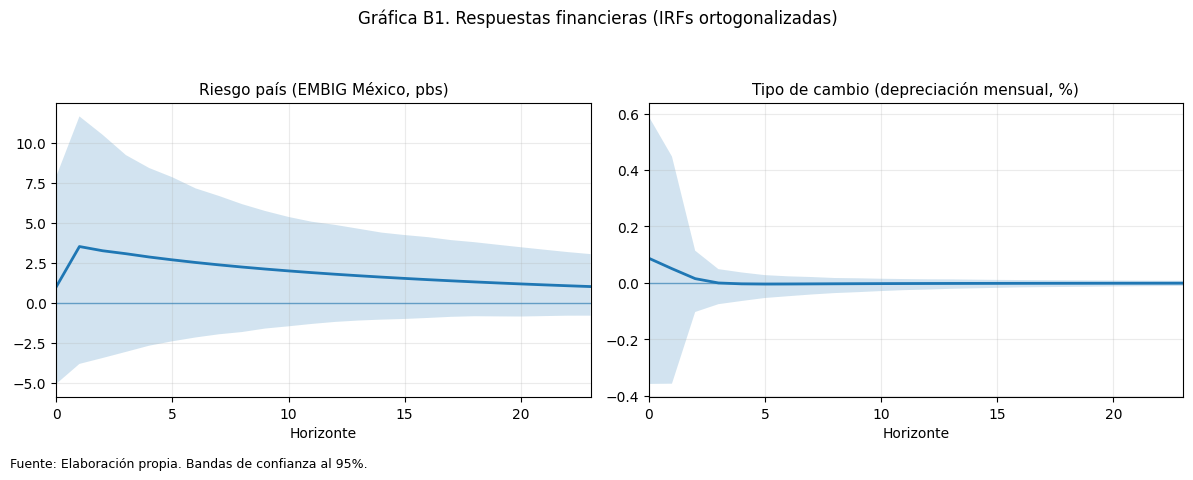

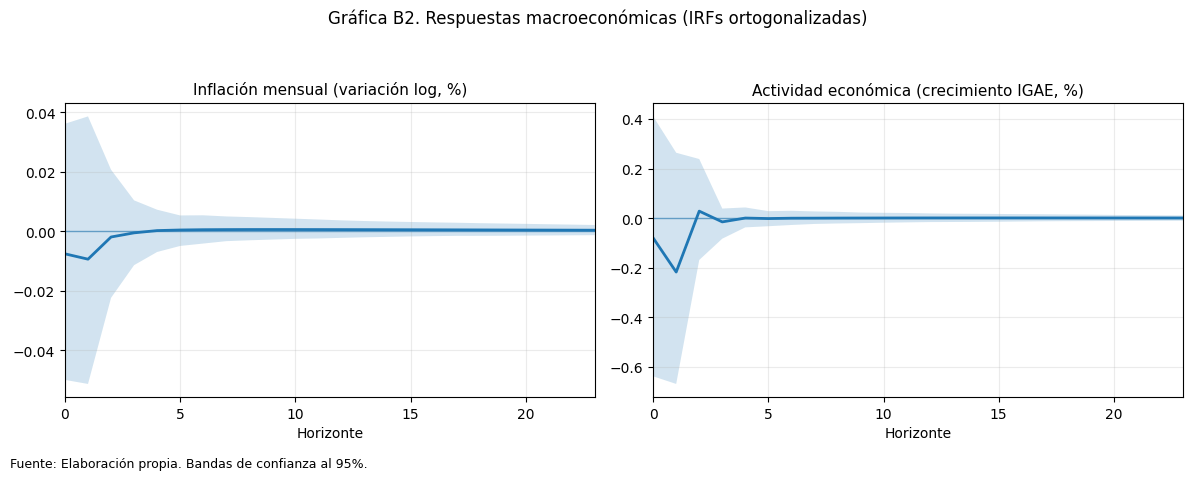

⚠️ No hay IRFs escaladas en irfs_dict (faltan orth_sc/lower_sc/upper_sc). Se omite.
⚠️ No hay IRFs escaladas en irfs_dict (faltan orth_sc/lower_sc/upper_sc). Se omite.


In [110]:
# =========================
# IRF panels (Banxico-style) — BLOQUE COMPLETO CORREGIDO (SIN depender de `orth`)
# =========================

import numpy as np
import matplotlib.pyplot as plt

def plot_irf_panels_banxico(
    responses,
    irfs_dict,
    main_title="",
    figure_note="",
    scaled=False,
    h=24,
    pretty_map=None
):
    """
    responses : list[str]
        Variables a graficar (nombres tal como aparecen en las columnas de los DataFrames).
    irfs_dict : dict
        Debe contener:
          - Baseline:  {"orth": df, "lower": df, "upper": df}
          - Escaladas (opcional): {"orth_sc": df, "lower_sc": df, "upper_sc": df}
        donde cada df tiene columnas = variables, filas = horizonte.
    scaled : bool
        Si True usa *_sc; si no existen, avisa y se sale.
    h : int
        Horizonte (0..h-1).
    pretty_map : dict
        Mapa para títulos bonitos.
    """

    # ---- Selección baseline vs escaladas ----
    if scaled:
        need = ("orth_sc", "lower_sc", "upper_sc")
        if not all(k in irfs_dict and irfs_dict[k] is not None for k in need):
            print("⚠️ No hay IRFs escaladas en irfs_dict (faltan orth_sc/lower_sc/upper_sc). Se omite.")
            return
        Y, LO, HI = irfs_dict["orth_sc"], irfs_dict["lower_sc"], irfs_dict["upper_sc"]
    else:
        need = ("orth", "lower", "upper")
        if not all(k in irfs_dict and irfs_dict[k] is not None for k in need):
            raise NameError(
                "No encuentro las IRFs baseline. Asegúrate de tener en `irfs_dict` las llaves: "
                "'orth', 'lower', 'upper'."
            )
        Y, LO, HI = irfs_dict["orth"], irfs_dict["lower"], irfs_dict["upper"]

    # ---- Helper: extraer serie por variable (DataFrame) ----
    def _get_series(df, var):
        if not (hasattr(df, "columns") and hasattr(df, "__getitem__")):
            raise TypeError("Pasa IRFs como pandas.DataFrame (columnas = variables).")
        if var not in df.columns:
            raise KeyError(f"La variable '{var}' no está en las columnas del IRF. Columnas: {list(df.columns)[:10]}...")
        return df[var].to_numpy()

    # ---- Horizonte ----
    x = np.arange(h)

    # ---- Figura ----
    n = len(responses)
    fig, axes = plt.subplots(1, n, figsize=(12, 4.8), sharey=False)
    if n == 1:
        axes = [axes]

    fig.suptitle(main_title, y=0.98, fontsize=12)

    for ax, var in zip(axes, responses):
        y  = _get_series(Y,  var)[:h]
        lo = _get_series(LO, var)[:h]
        hi = _get_series(HI, var)[:h]

        ax.fill_between(x, lo, hi, alpha=0.20, linewidth=0)
        ax.plot(x, y, linewidth=2)
        ax.axhline(0, linewidth=1, alpha=0.6)

        label = pretty_map.get(var, var) if isinstance(pretty_map, dict) else var
        ax.set_title(label, fontsize=11)

        ax.set_xlim(0, h - 1)
        ax.set_xlabel("Horizonte")
        ax.grid(True, alpha=0.25)

    fig.text(0.01, 0.02, figure_note, ha="left", va="bottom", fontsize=9)
    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    plt.show()


# =========================
# CONSTRUYE irfs_dict CON TUS NOMBRES REALES (esto evita el NameError)
# =========================
# ⚠️ Cambia estas 3 líneas para apuntar a las variables que SÍ tienes en tu notebook.
# Por ejemplo, si tus DataFrames se llaman irf_orth_df, irf_lo_df, irf_hi_df, cámbialo abajo.
idx = {name: i for i, name in enumerate(varnames)}

def irf_cube_to_df(cube, varnames, impulse_name, H, idx_map):
    """
    cube: np.ndarray (H+1, k, k)
          cube[h, response_i, shock_j]
    Regresa DataFrame (H+1 x k) con columnas=varnames, filas=horizonte,
    fijando shock_j = impulse.
    """
    if cube is None:
        return None
    if not isinstance(cube, np.ndarray) or cube.ndim != 3:
        raise TypeError("cube debe ser np.ndarray 3D con shape (H+1, k, k).")
    if impulse_name not in idx_map:
        raise KeyError(f"impulse='{impulse_name}' no está en varnames. Opciones: {list(idx_map.keys())}")
    j = idx_map[impulse_name]
    # Tomamos todas las respuestas i, fijando shock j
    mat = cube[:H+1, :, j]  # (H+1, k)
    return pd.DataFrame(mat, columns=varnames)

# Baseline
orth_df  = irf_cube_to_df(orth,  varnames, impulse, H, idx)
lower_df = irf_cube_to_df(lower, varnames, impulse, H, idx)
upper_df = irf_cube_to_df(upper, varnames, impulse, H, idx)

# Escaladas (si existen)
orth_sc_df  = irf_cube_to_df(globals().get("orth_sc"),  varnames, impulse, H, idx)
lower_sc_df = irf_cube_to_df(globals().get("lower_sc"), varnames, impulse, H, idx)
upper_sc_df = irf_cube_to_df(globals().get("upper_sc"), varnames, impulse, H, idx)

# irfs_dict ahora SÍ cumple lo que espera tu plotter (DataFrames con columnas)
irfs_dict = {
    "orth": orth_df,
    "lower": lower_df,
    "upper": upper_df,
    "orth_sc": orth_sc_df,
    "lower_sc": lower_sc_df,
    "upper_sc": upper_sc_df,
}

# (Opcional) sanity check
print("IRFs DF shapes:",
      {k: (v.shape if v is not None else None) for k, v in irfs_dict.items()})
print("Columnas disponibles (primeras 10):", list(orth_df.columns)[:10])

# =========================
# 2) Tus gráficas (ya no truena)
# =========================
b1_vars = ["EMBIG", "dlog_fx"]
b2_vars = ["infl_m", "g_igae"]

plot_irf_panels_banxico(
    responses=b1_vars,
    irfs_dict=irfs_dict,
    main_title="Gráfica B1. Respuestas financieras (IRFs ortogonalizadas)",
    figure_note="Fuente: Elaboración propia. Bandas de confianza al 95%.",
    scaled=False,
    h=H,
    pretty_map=pretty
)

plot_irf_panels_banxico(
    responses=b2_vars,
    irfs_dict=irfs_dict,
    main_title="Gráfica B2. Respuestas macroeconómicas (IRFs ortogonalizadas)",
    figure_note="Fuente: Elaboración propia. Bandas de confianza al 95%.",
    scaled=False,
    h=H,
    pretty_map=pretty
)

# Dot-com (si no existen *_sc_df, tu función avisa y se salta)
plot_irf_panels_banxico(
    responses=b1_vars,
    irfs_dict=irfs_dict,
    main_title="Gráfica B1. Escenario dot-com: respuestas financieras",
    figure_note="Fuente: Elaboración propia. IRFs escaladas con la caída histórica del Nasdaq. Bandas al 95%.",
    scaled=True,
    h=H,
    pretty_map=pretty
)

plot_irf_panels_banxico(
    responses=b2_vars,
    irfs_dict=irfs_dict,
    main_title="Gráfica B2. Escenario dot-com: respuestas macroeconómicas",
    figure_note="Fuente: Elaboración propia. IRFs escaladas con la caída histórica del Nasdaq. Bandas al 95%.",
    scaled=True,
    h=H,
    pretty_map=pretty
)

## 📌 Interpretación económica del shock

El shock `tech_rel` mide un **movimiento relativo de los activos tecnológicos** frente al mercado accionario amplio:

\[
tech\_rel = r(\text{Nasdaq}) - r(\text{S\&P 500})
\]

Por lo tanto:

- 🔻 **Si `tech_rel` cae**  
  El Nasdaq rinde peor que el S&P 500  
  ⇒ **Caída específica del sector tecnológico**  
  (no es una caída general del mercado)

- 🔺 **Si `tech_rel` sube**  
  El Nasdaq sobre-rinde al S&P  
  ⇒ **Boom tecnológico**

---

## 📊 ¿Qué representa el IRF estimado?

Dado que el impulso en las IRFs es:

```python
impulse = "tech_rel"
y se analizan las respuestas de:

-EMBI (riesgo país)
-Tipo de cambio
-Inflación
-IGAE

lo que se está estimando es:

El efecto de un shock negativo en el sector tecnológico global
(tipo episodio dot-com) sobre variables financieras y macroeconómicas de México.

## Código para construir el Cuadro B2

In [111]:
import numpy as np
import pandas as pd

# === 1. Definir tamaño del shock dot-com ===
shock_dotcom = 0.26   # caída relativa Nasdaq vs S&P (26 pp)

# === 2. Escalar IRFs y bandas ===
orth_sc  = orth  * shock_dotcom
lower_sc = lower * shock_dotcom
upper_sc = upper * shock_dotcom

print("Escalamiento aplicado con shock_dotcom =", shock_dotcom)

# === 3. Construir Cuadro B2 ===
vars_b2 = ["EMBIG", "dlog_fx", "infl_m", "g_igae"]  # agrega tasaMX si ya la tienes

rows = []

for v in vars_b2:
    i = idx[v]
    j = idx["tech_rel"]

    serie = orth_sc[:, i, j]

    h_peak = int(np.argmax(np.abs(serie)))
    peak_val = float(serie[h_peak])

    rows.append({
        "Variable": v,
        "Máximo impacto": peak_val,
        "Mes del pico": h_peak
    })

cuadro_b2 = pd.DataFrame(rows)

# === 4. Formato Banxico ===
labels = {
    "EMBIG": "Prima de riesgo (EMBI)",
    "dlog_fx": "Tipo de cambio (depreciación, %)",
    "infl_m": "Inflación mensual",
    "g_igae": "Actividad económica (IGAE)"
}

cuadro_b2["Variable"] = cuadro_b2["Variable"].map(labels)
cuadro_b2["Máximo impacto"] = cuadro_b2["Máximo impacto"].round(2)

cuadro_b2 = cuadro_b2[["Variable", "Máximo impacto", "Mes del pico"]]

cuadro_b2

Escalamiento aplicado con shock_dotcom = 0.26


,Variable,Máximo impacto,Mes del pico
0,Prima de riesgo (EMBI),0.91,1
1,"Tipo de cambio (depreciación, %)",0.02,0
2,Inflación mensual,-0.00,1
3,Actividad económica (IGAE),-0.06,1
